# 04c — Alberta foothills results: candidate areas

Results for the ab_foothills run (`config.ANALYSES["ab_foothills"]`). **NEW candidate areas** = the small high-value areas surfaced with compactness off; **benchmark** = the existing PAs inside the foothills window. **Requires** `output_data/iter6_ab_foothills/` (run 03c first). **Kernel:** `.venv` (Python).

In [1]:
# ---- Setup: shared results engine + this analysis' key -------------------
import importlib
import results_core as rc, config
importlib.reload(config); importlib.reload(rc)

ANALYSIS = "ab_foothills"   # <-- the ONLY line that differs between 04a / 04b / 04c
A = rc.load(ANALYSIS)          # locate the run + region label + map outline + benchmark spec
rc.load_rasters(A)             # portfolio + selection-frequency rasters

analysis=ab_foothills | run=iter6_ab_foothills | objective=min_shortfall | proportion/LP
region=Alberta foothills | figures -> output_data/iter6_ab_foothills/figures
portfolio: 1 solution(s) | grid 551 x 891
allocation surface: 0.00..1.00


namespace(analysis='ab_foothills',
          a04={'region_label': 'Alberta foothills',
               'cluster_select': 'largest',
               'benchmark': {'type': 'named_pa',
                'featured': [('Castle Provincial Park', 'Castle PP'),
                 ('Peter Lougheed', 'Peter Lougheed PP'),
                 ('Siffleur', 'Siffleur Wilderness'),
                 ('Whitehorse Wildland', 'Whitehorse Wildland'),
                 ('Willmore', 'Willmore'),
                 ('Kakwa Wildland', 'Kakwa Wildland')]},
               'benchmark_title': 'AB provincial PAs (N–S spread)',
               'manual_area': None,
               'outline_label': 'foothills extent',
               'context_outline': '/Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/input_data/alberta_boundary/alberta.gpkg',
               'context_label': 'Alberta',
               'frame': 'context'},
          run_dir=PosixPath('/Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimiza

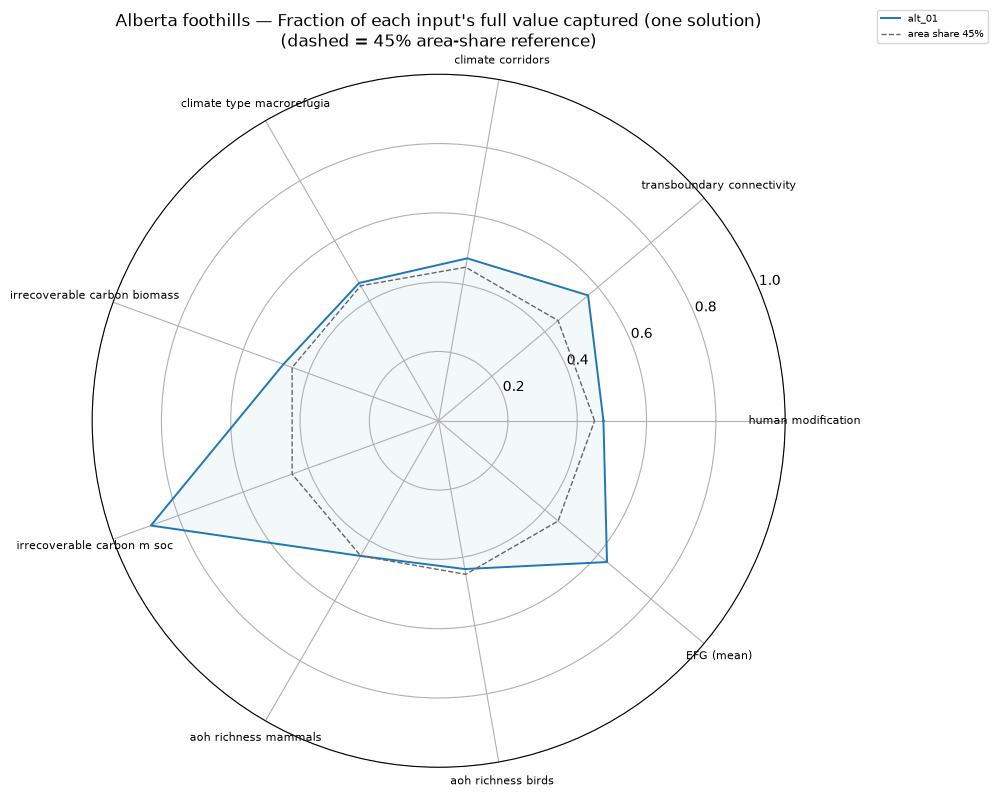

In [2]:
# ---- Radar: captured fraction per input vs the area-share ring ----
rc.radar(A)

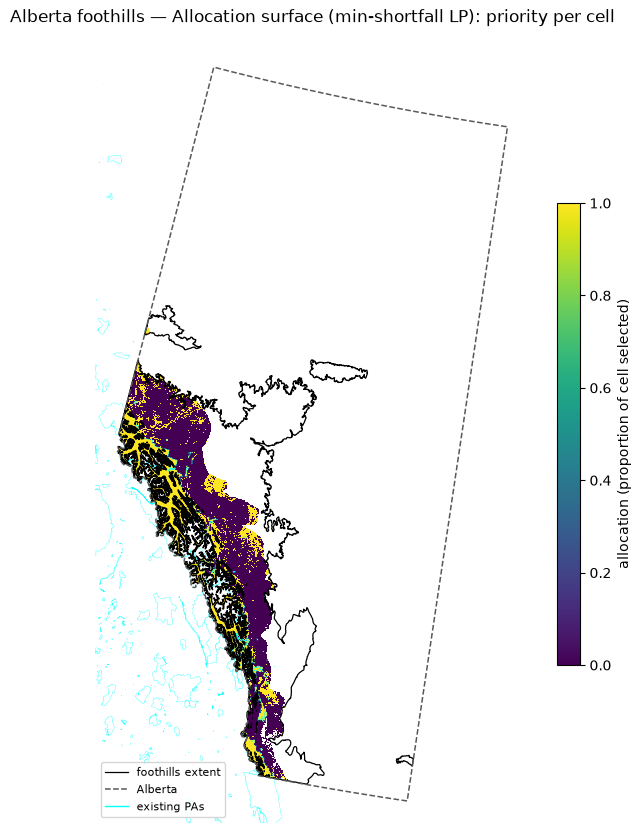

In [3]:
# ---- Allocation surface / selection-frequency map ----
rc.allocation_map(A)

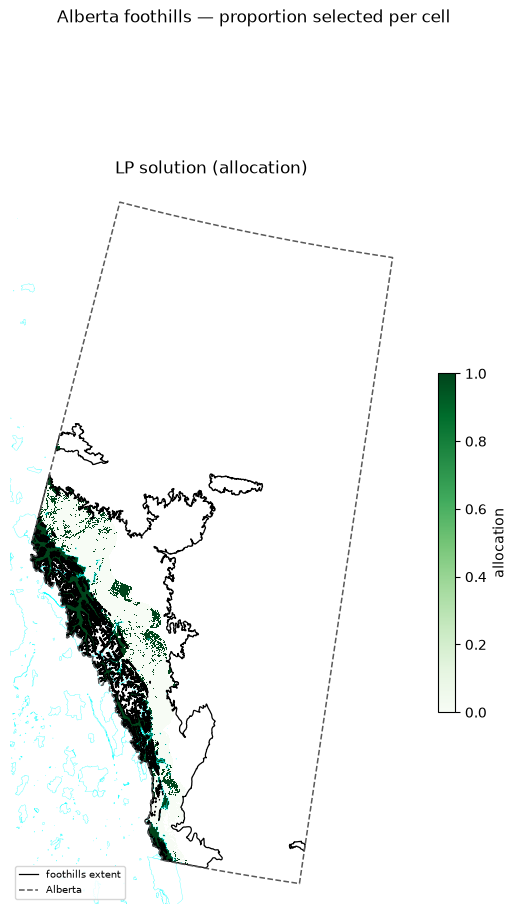

In [4]:
# ---- Solution map(s) ----
rc.solution_maps(A)

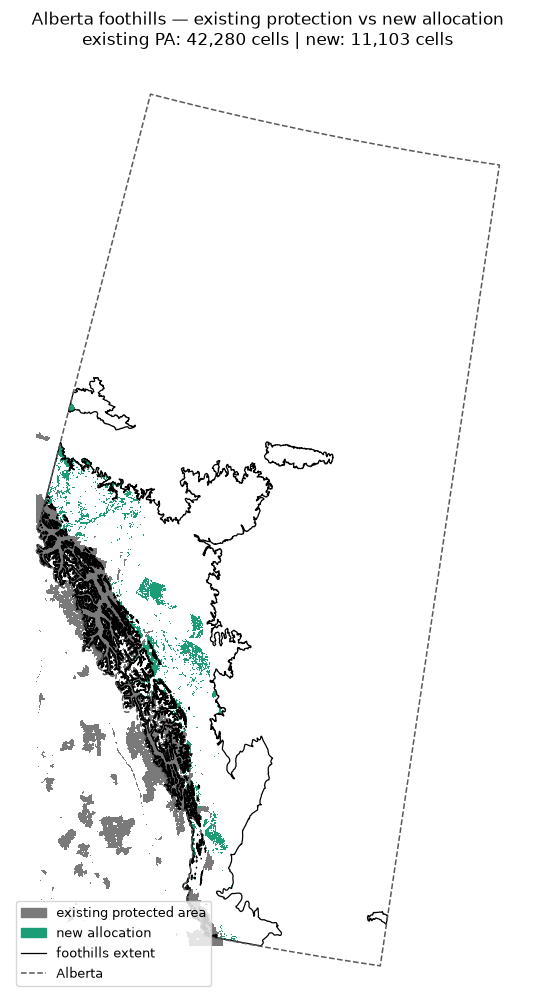

In [5]:
# ---- Existing protection vs new allocation ----
rc.existing_vs_new(A)

In [6]:
# ---- Trade-off table + headline stats ----
rc.tradeoff(A)

Per-solution summary:
alternative  n_selected  pct_region  n_added_beyond_pa
     alt_01    34225.65          45              11102

window planning units : 76,057
area budget (cells)   : 34,226 (45%)
locked-in             : 23,123 (30.4% of window)
area selected         : 45.0% of window


## Candidate areas vs the existing-protection benchmark

`build_stacks` loads the feature stacks, computes **full-Y2Y** region totals (so contribution / efficiency stay “% of Y2Y”), and profiles: the **NEW candidate areas** (connected blocks of new allocation) and the analysis' **benchmark** block (y2y: featured parks + Ross River; north_bc: the 4 IPCA anchors; ab_foothills: the existing in-window PAs). Each area gets three star-plot views + the consequences tables. Figures/CSVs → the run's folder.

In [7]:
# ---- Build stacks + profile NEW clusters + benchmark block (+ manual area) ----
rc.build_stacks(A)

new candidate areas   : 609 components, 6 kept (>= 25 cells, largest)
benchmark areas       : 6 profiled [named_pa]
cell size 1.0 km^2 | full-Y2Y PU denom = 1,272,914
shared efficiency scale EFF_RMAX = 0.40 %/1,000 km^2


namespace(analysis='ab_foothills',
          a04={'region_label': 'Alberta foothills',
               'cluster_select': 'largest',
               'benchmark': {'type': 'named_pa',
                'featured': [('Castle Provincial Park', 'Castle PP'),
                 ('Peter Lougheed', 'Peter Lougheed PP'),
                 ('Siffleur', 'Siffleur Wilderness'),
                 ('Whitehorse Wildland', 'Whitehorse Wildland'),
                 ('Willmore', 'Willmore'),
                 ('Kakwa Wildland', 'Kakwa Wildland')]},
               'benchmark_title': 'AB provincial PAs (N–S spread)',
               'manual_area': None,
               'outline_label': 'foothills extent',
               'context_outline': '/Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/input_data/alberta_boundary/alberta.gpkg',
               'context_label': 'Alberta',
               'frame': 'context'},
          run_dir=PosixPath('/Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimiza

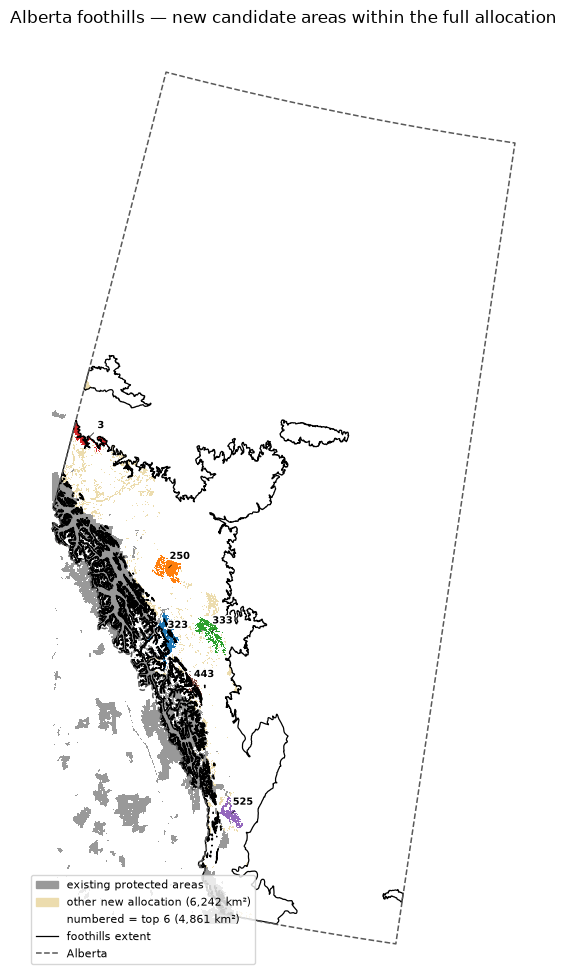

In [8]:
# ---- New candidate areas: map (colored, numbered) within the full allocation ----
rc.new_map(A)

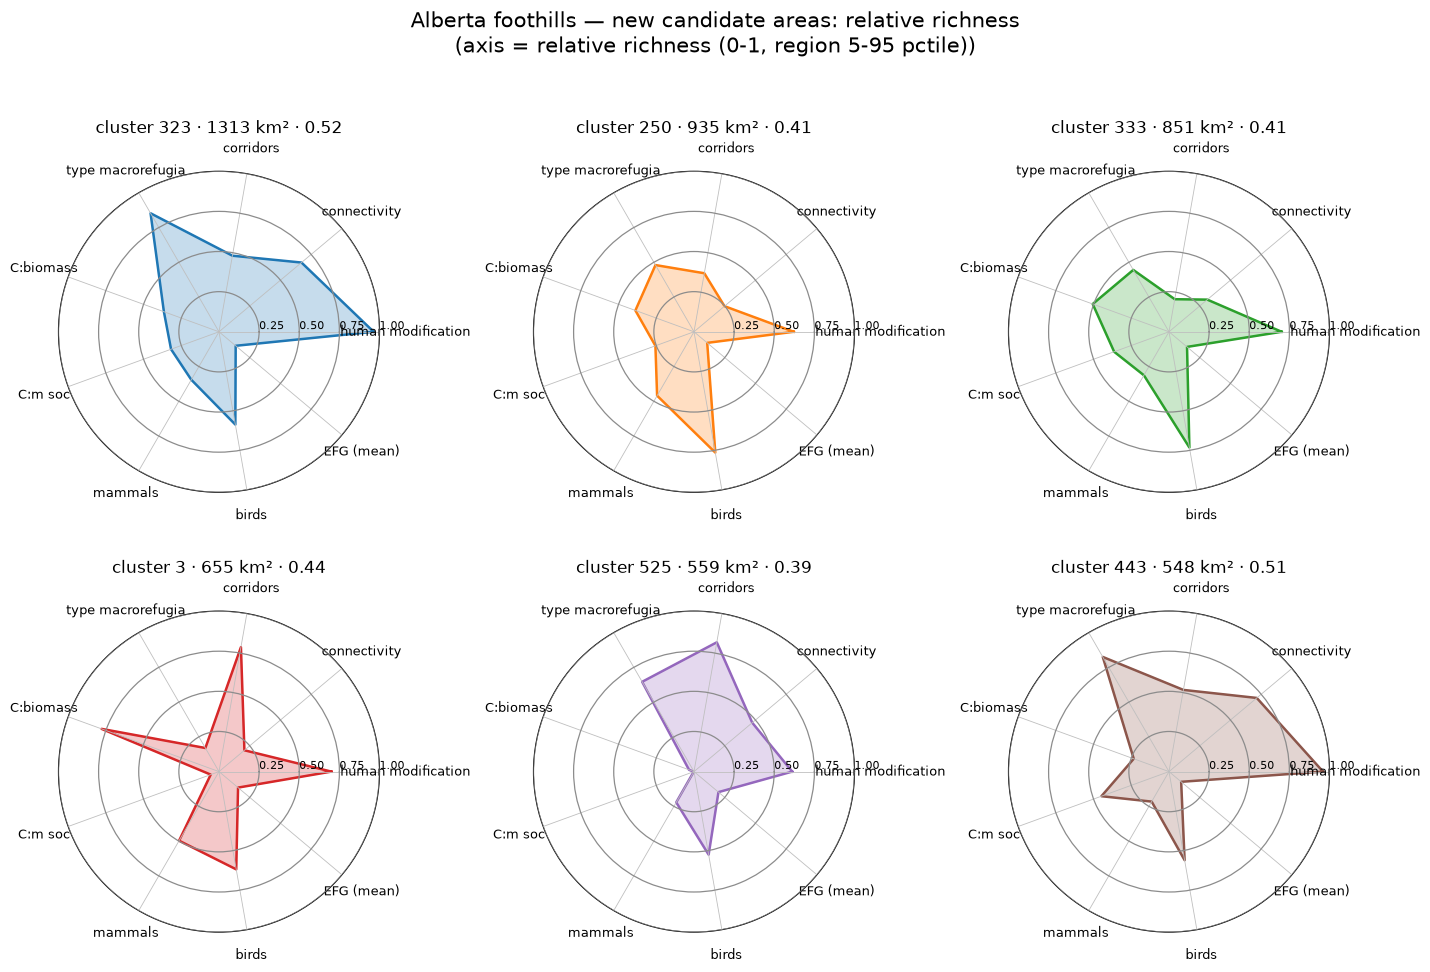

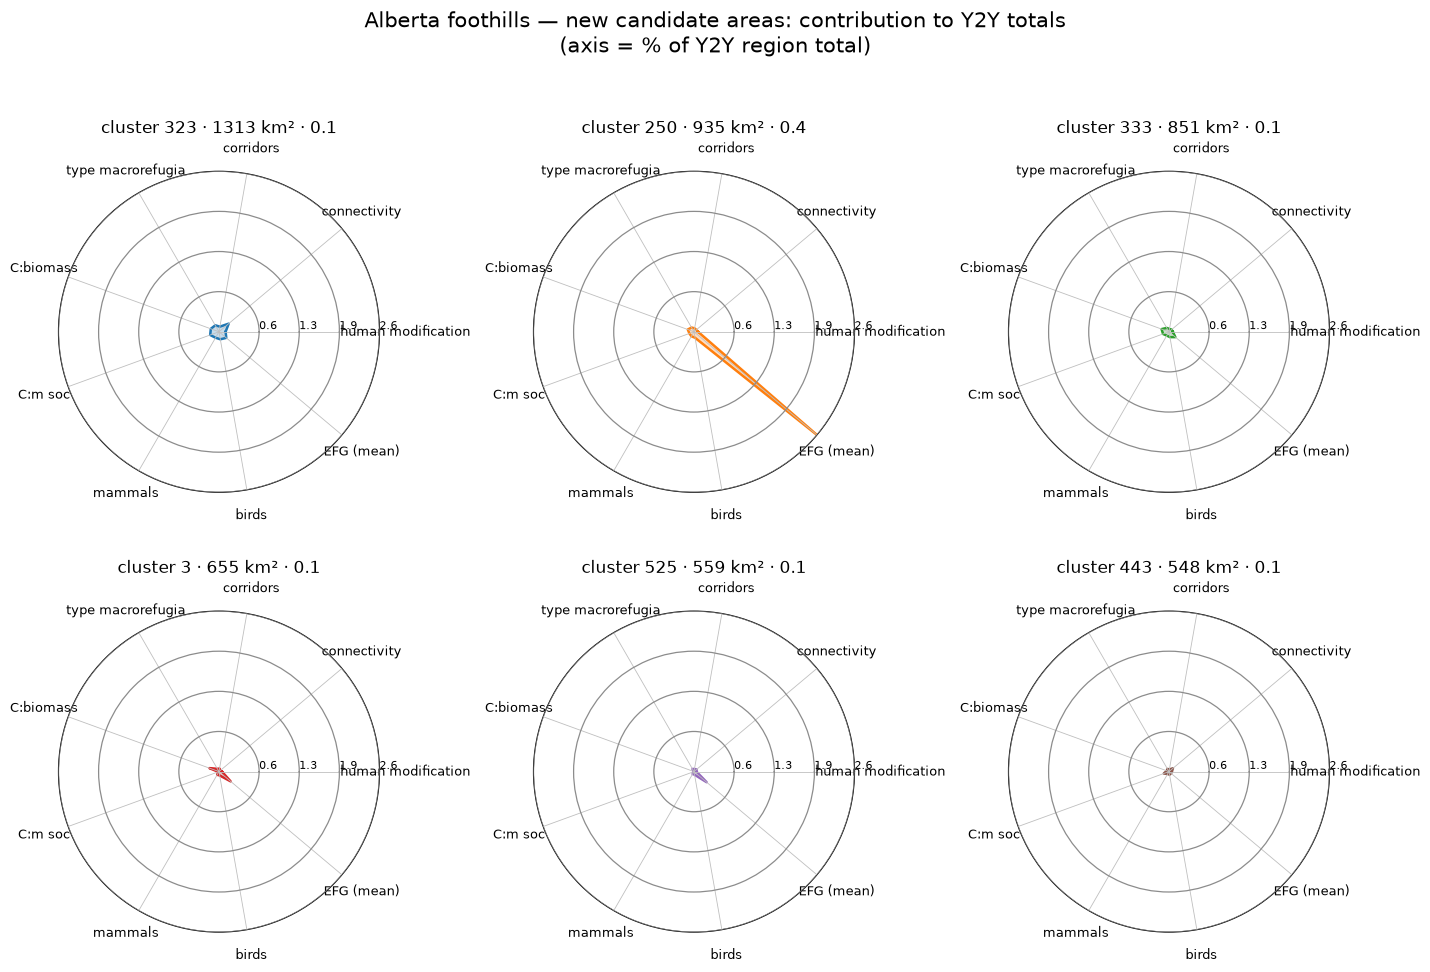

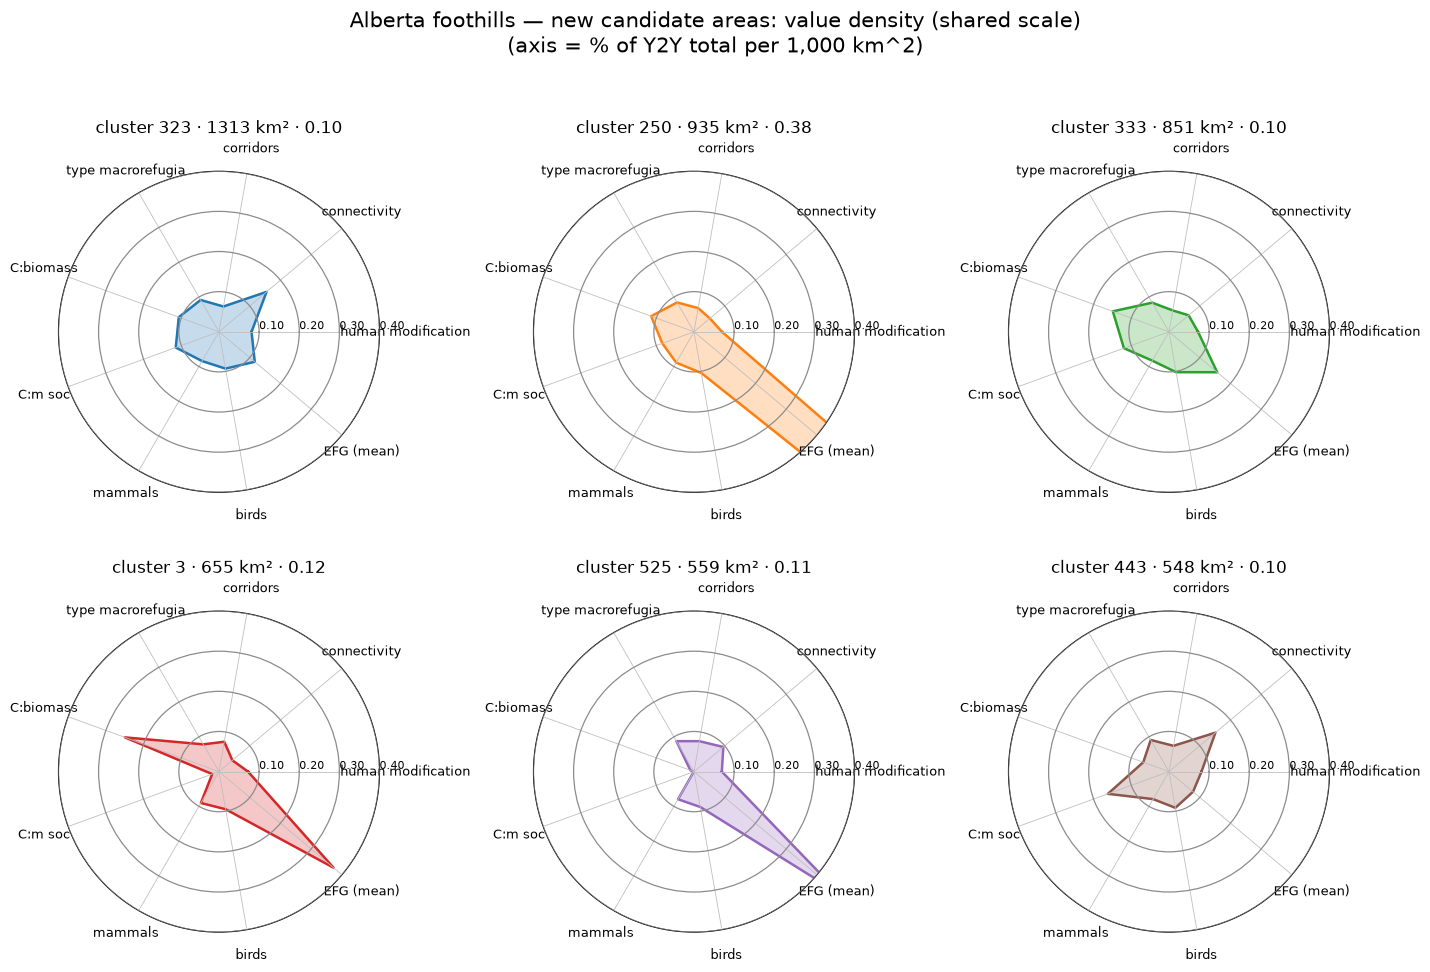

In [9]:
# ---- New candidate areas: 3 star-plot views (richness / contribution / efficiency) ----
rc.new_stars(A)

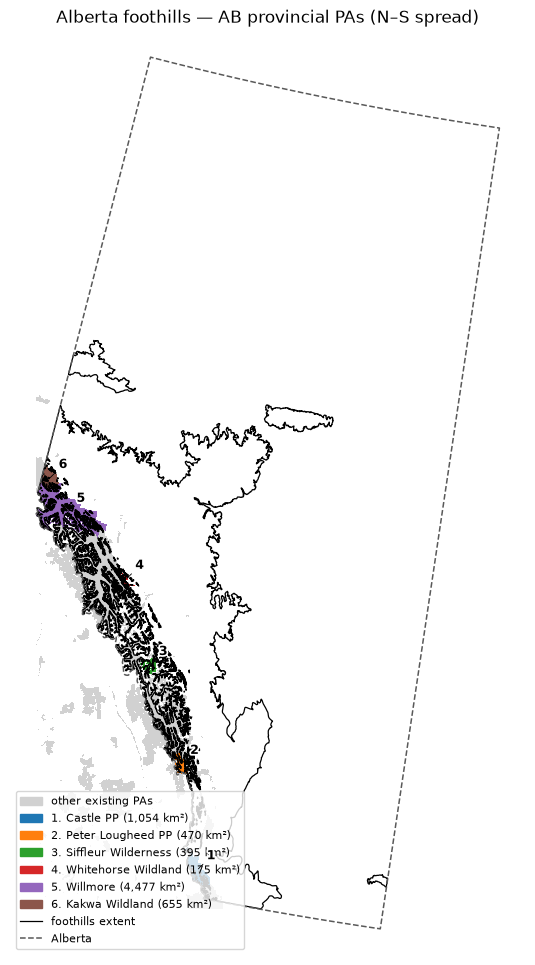

In [10]:
# ---- Benchmark areas: map ----
rc.bench_map(A)

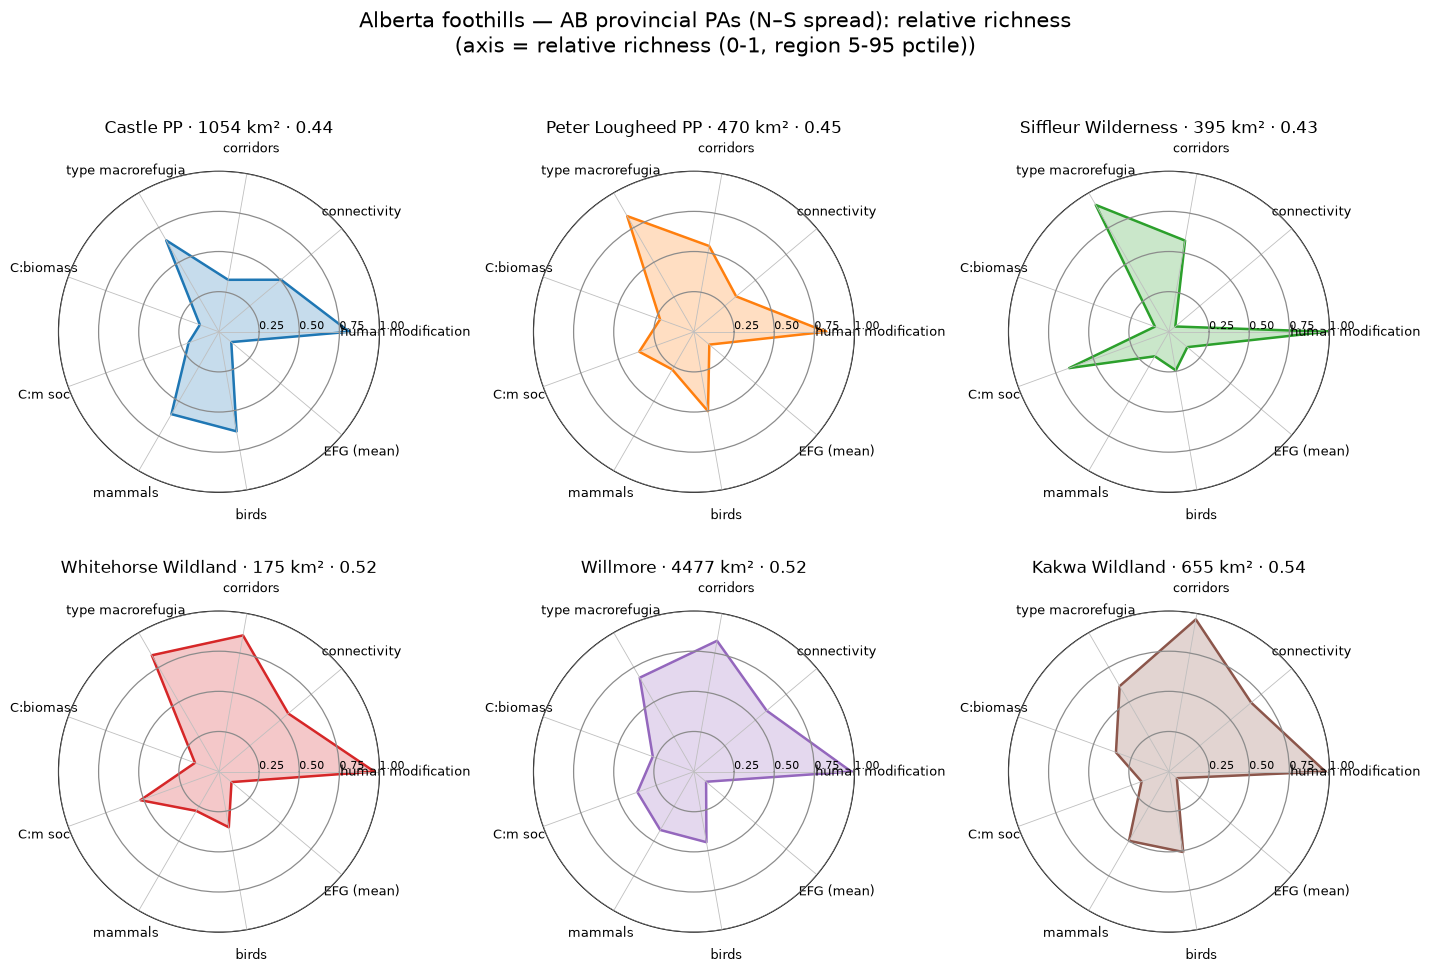

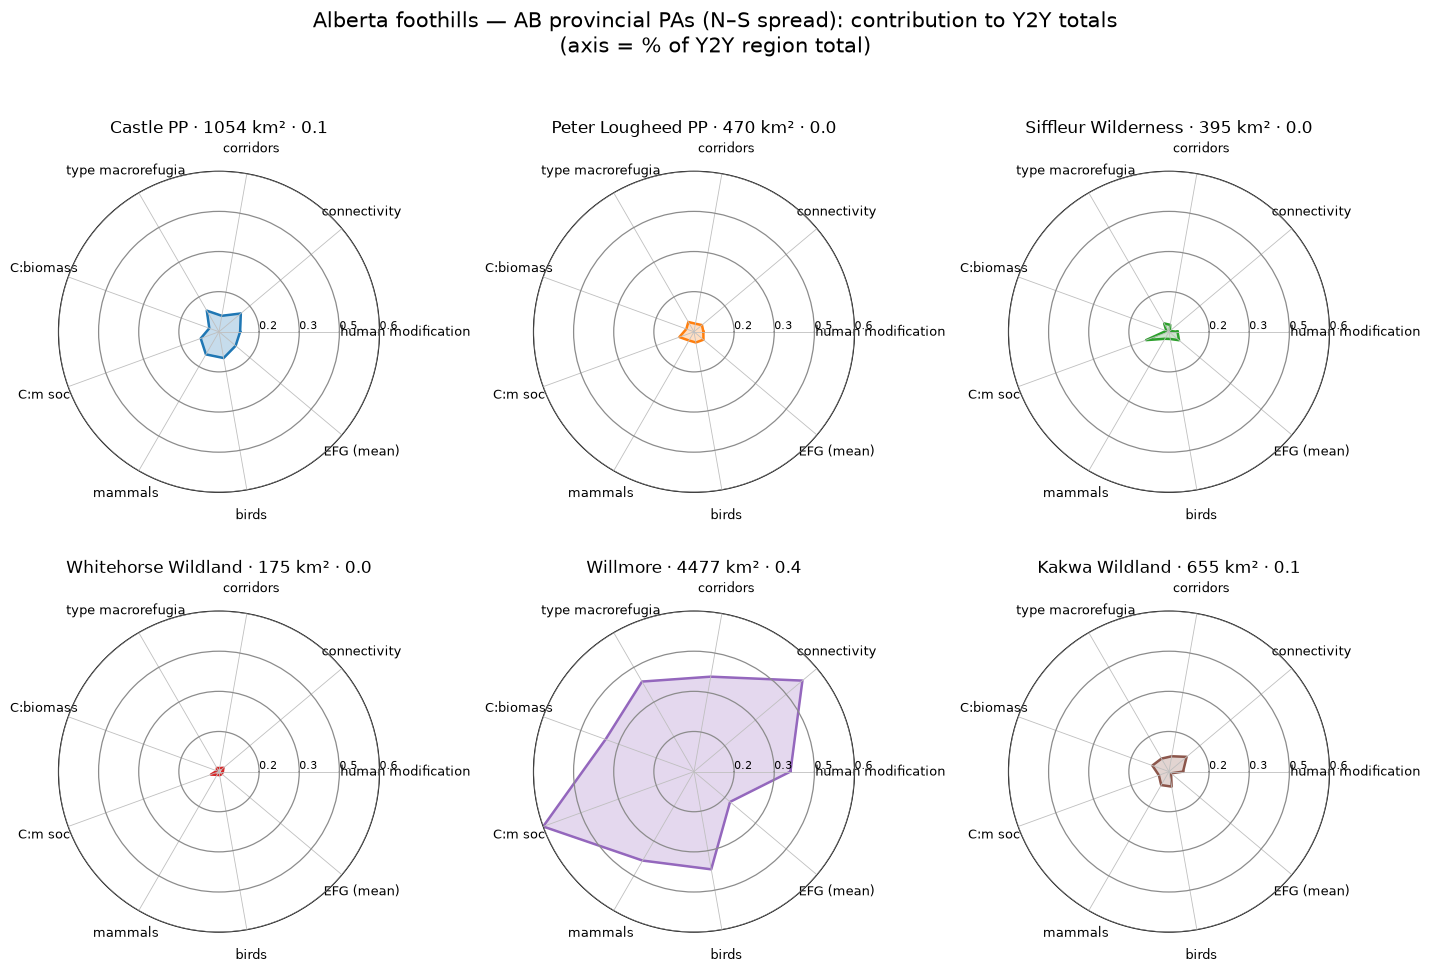

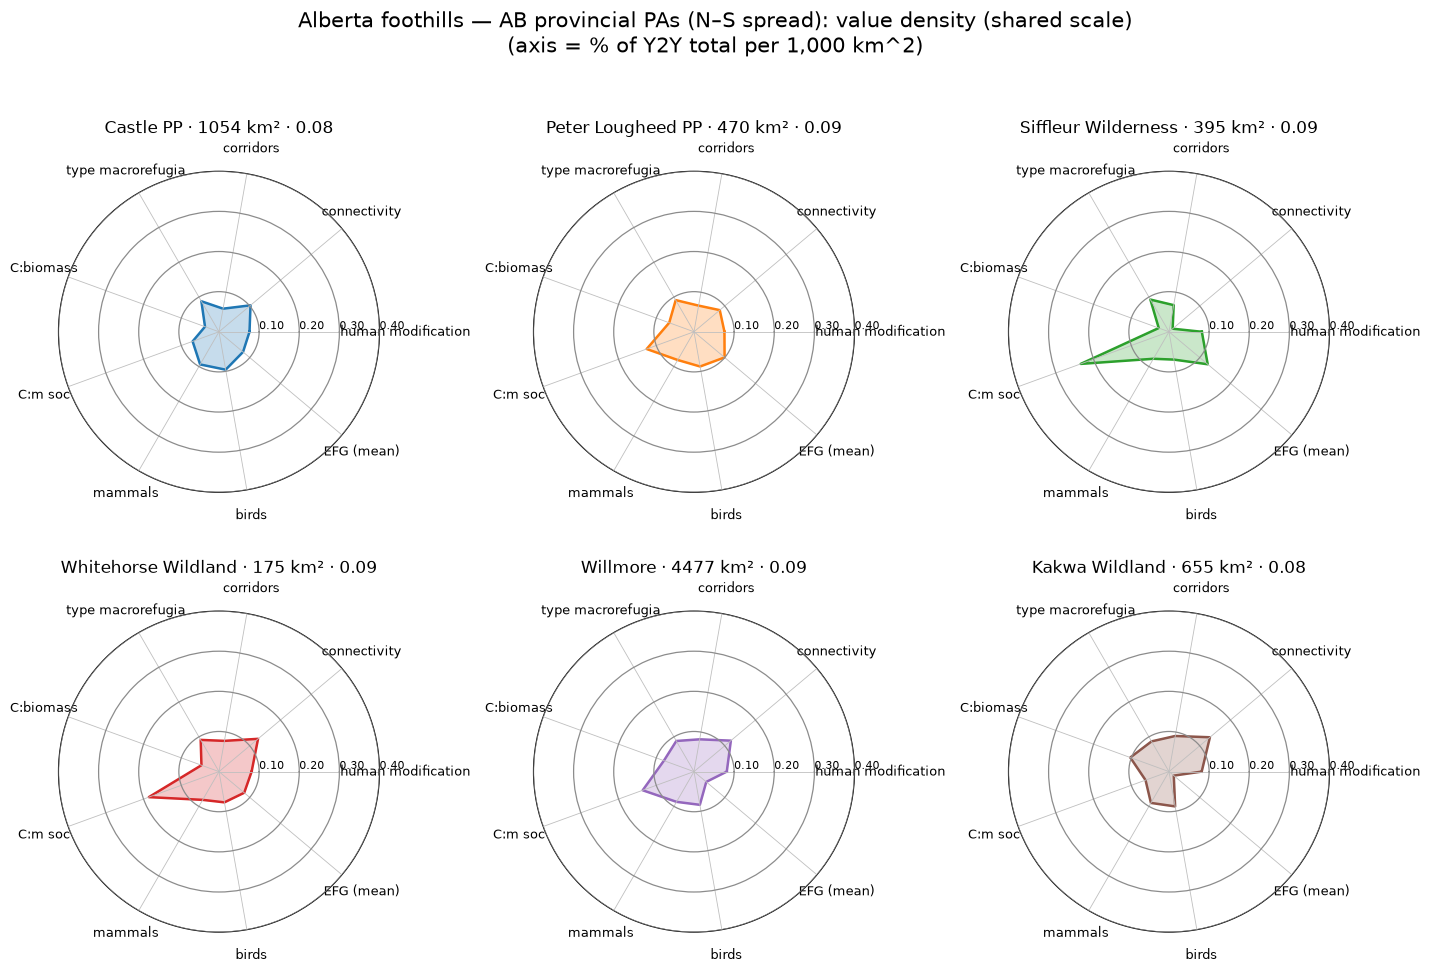

In [11]:
# ---- Benchmark areas: 3 star-plot views ----
rc.bench_stars(A)

In [12]:
# ---- Manual area (Ross River for y2y; no-op for the sub-regions) ----
rc.manual_block(A)

no manual area for this analysis


In [13]:
# ---- Consequences: transposed decision matrices (contribution / efficiency / raw) ----
rc.consequences(A)

CONTRIBUTION (% of Y2Y total):
                                                                                                                          NEW-323  NEW-250  NEW-333   NEW-3  NEW-525  NEW-443  Castle PP  Peter Lougheed PP  Siffleur Wilderness  Whitehorse Wildland  Willmore  Kakwa Wildland
Contribution = area's share of the Y2Y region-wide total per input (%). Rows: 2 area metrics + 9 inputs; columns: areas.                                                                                                                                                       
area (km^2)                                                                                                                1313.0   935.00   851.00  655.00   559.00   548.00    1054.00             470.00               395.00               175.00   4477.00          655.00
area (% of Y2Y)                                                                                                               0.1     0.07     0.07    0.

(                                                    NEW-323  NEW-250  NEW-333   NEW-3  NEW-525  NEW-443  Castle PP  Peter Lougheed PP  Siffleur Wilderness  Whitehorse Wildland  Willmore  Kakwa Wildland
 Contribution = area's share of the Y2Y region-w...                                                                                                                                                       
 area (km^2)                                          1313.0   935.00   851.00  655.00   559.00   548.00    1054.00             470.00               395.00               175.00   4477.00          655.00
 area (% of Y2Y)                                         0.1     0.07     0.07    0.05     0.04     0.04       0.08               0.04                 0.03                 0.01      0.35            0.05
 Intactness                                              0.1     0.10     0.10    0.00     0.00     0.00       0.10               0.00                 0.00                 0.00      0.40  

In [14]:
# ---- Plain-language strongest / weakest summary per area ----
rc.plain_language(A)

Alberta foothills — per-area strongest / weakest inputs (by relative richness):

  NEW-323                strongest: Intactness, Climate refugia, Connectivity   |   weakest: Ecosystem groups (EFG), Carbon: mineral soil, Mammal richness
  NEW-250                strongest: Bird richness, Intactness, Climate refugia   |   weakest: Ecosystem groups (EFG), Connectivity, Carbon: mineral soil
  NEW-333                strongest: Bird richness, Intactness, Carbon: biomass   |   weakest: Ecosystem groups (EFG), Climate corridors, Connectivity
  NEW-3                  strongest: Climate corridors, Carbon: biomass, Intactness   |   weakest: Carbon: mineral soil, Ecosystem groups (EFG), Climate refugia
  NEW-525                strongest: Climate corridors, Climate refugia, Intactness   |   weakest: Carbon: mineral soil, Carbon: biomass, Ecosystem groups (EFG)
  NEW-443                strongest: Intactness, Climate refugia, Connectivity   |   weakest: Ecosystem groups (EFG), Mammal richness, Carbon:

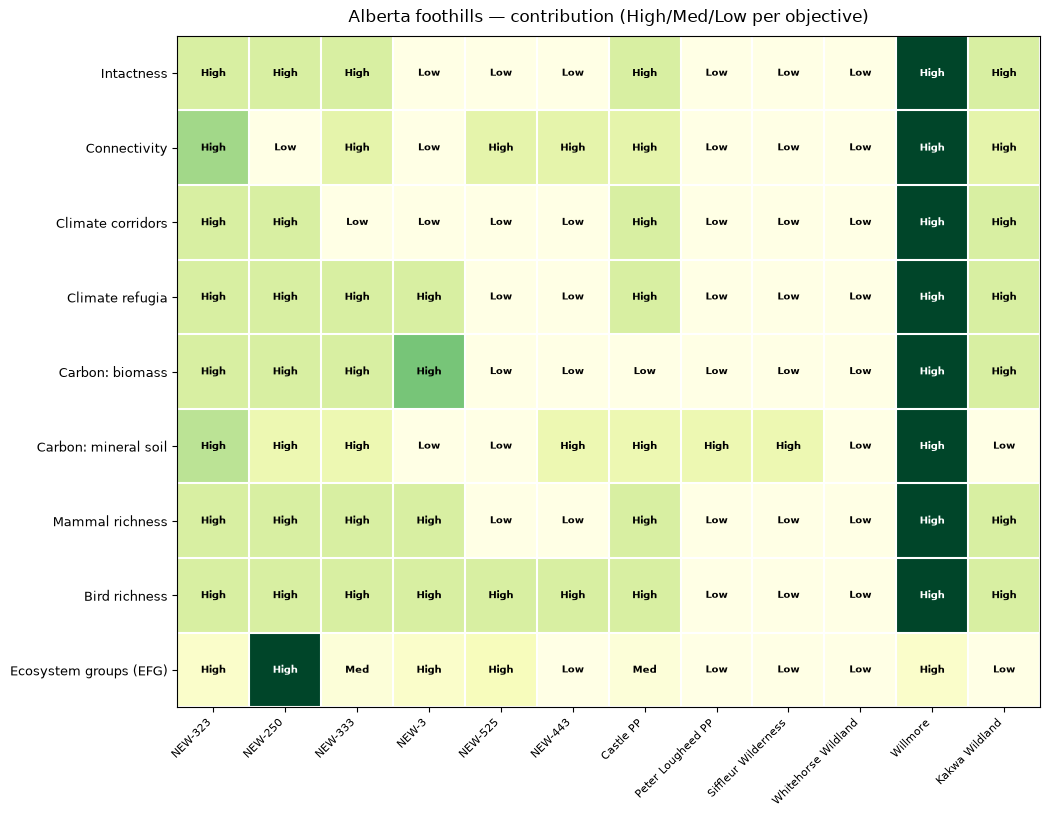

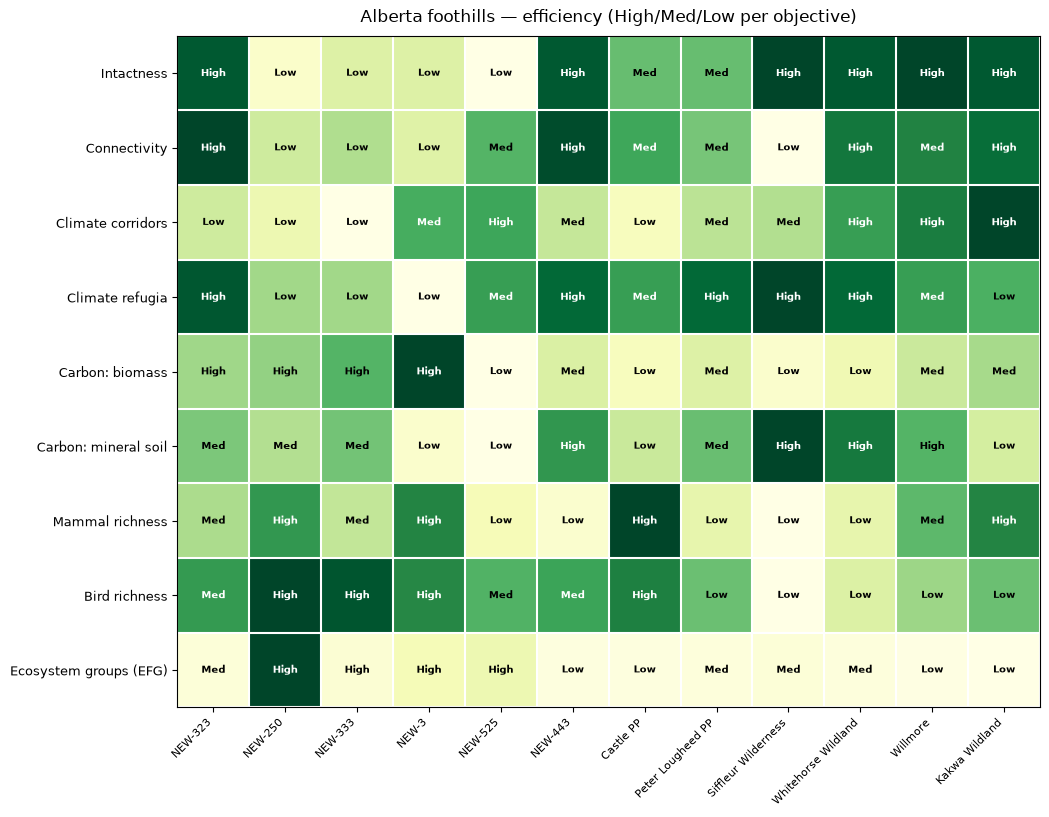

In [15]:
# ---- Colors-only High/Med/Low heatmaps (workshop / accessibility) ----
rc.heatmaps(A)